In [ ]:
xw!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git
!pip install faiss-cpu

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-vqm28az5
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-vqm28az5
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done


In [ ]:
import torch, clip, faiss, os
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Configuration des chemins à surrement addapter
SAVE_DIR = "/content/drive/MyDrive/Projet_MIR/aPartie 2/save/"
IMAGES_PATH = "/content/drive/MyDrive/Projet_MIR/aPartie 2/dataset/archive (Unzipped Files)/Images/"
CAPTIONS_FILE = "/content/drive/MyDrive/Projet_MIR/aPartie 2/dataset/archive (Unzipped Files)/captions.txt"

# Montage du drive (si nécessaire)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

df = pd.read_csv(CAPTIONS_FILE)
unique_imgs = df['image'].unique()

# Chargement des index
index_img = faiss.read_index(os.path.join(SAVE_DIR, "index_images.faiss"))
index_txt = faiss.read_index(os.path.join(SAVE_DIR, "index_captions.faiss"))

print("✅ Moteur prêt.")

✅ Moteur prêt.


In [ ]:
def query_text_to_image(text_query, k=5):
    with torch.no_grad():
        tokens = clip.tokenize([text_query], truncate=True).to(device)
        query_vec = model.encode_text(tokens)
        query_vec /= query_vec.norm(dim=-1, keepdim=True)
    distances, indices = index_img.search(query_vec.cpu().numpy().astype('float32'), k)
    return [{"name": unique_imgs[indices[0][i]], "path": os.path.join(IMAGES_PATH, unique_imgs[indices[0][i]]), "score": float(distances[0][i])} for i in range(k)]

def query_image_to_text(image_path, k=5):
    img = preprocess(Image.open(image_path)).unsqueeze(0).to(device)
    with torch.no_grad():
        query_vec = model.encode_image(img)
        query_vec /= query_vec.norm(dim=-1, keepdim=True)
    distances, indices = index_txt.search(query_vec.cpu().numpy().astype('float32'), k)
    return [{"caption": df.iloc[indices[0][i]]['caption'], "score": float(distances[0][i])} for i in range(k)]

def display_results(query, is_text=True, k=3):
    if is_text:
        res = query_text_to_image(query, k)
        plt.figure(figsize=(15, 5))
        for i, r in enumerate(res):
            plt.subplot(1, k, i+1)
            plt.imshow(Image.open(r['path']))
            plt.title(f"Score: {r['score']:.3f}")
            plt.axis('off')
    else:
        res = query_image_to_text(query, k)
        print(f"Résultats pour l'image : {os.path.basename(query)}")
        for i, r in enumerate(res): print(f"{i+1}. {r['caption']} (Score: {r['score']:.2f})")
    plt.show()

🔍 TEST 1 : RECHERCHE TEXTE VERS IMAGES


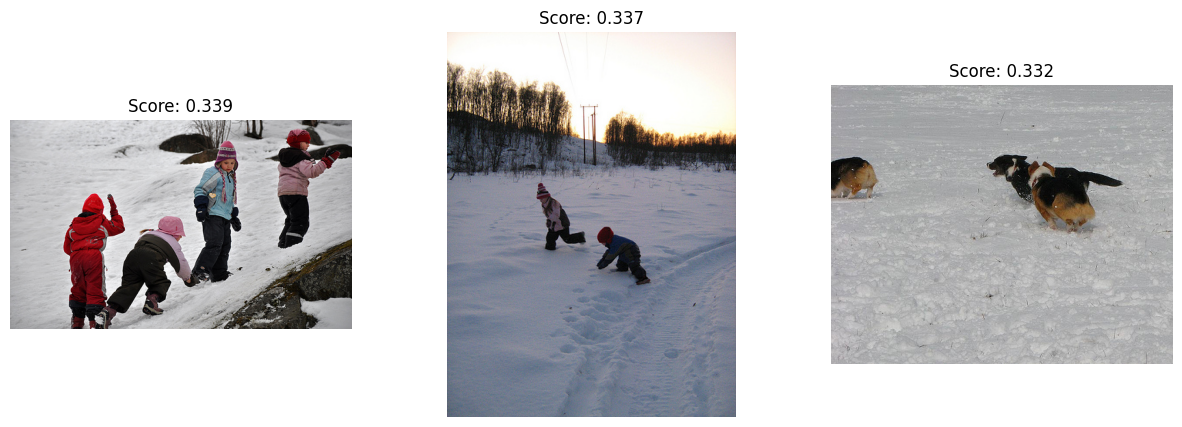



📸 TEST 2 : RECHERCHE IMAGE VERS TEXTES (RECHERCHE INVERSE)
Résultats pour l'image : 1131340021_83f46b150a.jpg
1. A young boy runs along a boardwalk towards a pigeon . (Score: 0.36)
2. A young boy wearing blue jumps off of a cement sidewalk . (Score: 0.35)
3. A boy wearing skates sliding down concrete railing of steps near a pole . (Score: 0.35)
4. Young boy running waring blue jacket and blue jeans , flower pots are in the background on a cement walkway . (Score: 0.35)
5. A boy runs near some steps . (Score: 0.35)


In [ ]:
# --- EXEMPLES D'UTILISATION ---

print("🔍 TEST 1 : RECHERCHE TEXTE VERS IMAGES")
# Remplace la requête par ce que tu veux tester
ma_requete_texte = "A group of children playing in the snow"
display_results(ma_requete_texte, is_text=True, k=3)

print("\n" + "="*50 + "\n")

print("📸 TEST 2 : RECHERCHE IMAGE VERS TEXTES (RECHERCHE INVERSE)")
# On sélectionne une image au hasard dans le dataset pour le test
# unique_imgs[123] est un exemple, tu peux changer l'index
image_test_nom = unique_imgs[123]
image_test_path = os.path.join(IMAGES_PATH, image_test_nom)

display_results(image_test_path, is_text=False, k=5)